Loading PaPaGei model

In [2]:
import os
import re
import sys
import sys 
import numpy as np
import pandas as pd
import torch
import h5py
from tqdm import tqdm
import torch.nn as nn

In [3]:
import random

SEED = 100

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CUDA operations deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
import sys

repo_path = "/data1/yashvi_bhuva/BP_estimation_using_PPG/PPG_BP/PaPaGei/papagei-foundation-model"

if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

from linearprobing.utils import resample_batch_signal, load_model_without_module_prefix
from models.resnet import ResNet1DMoE


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_config = {
    "base_filters": 32,
    "kernel_size": 3,
    "stride": 2,
    "groups": 1,
    "n_block": 18,
    "n_classes": 512,
    "n_experts": 3
}


papagei_model = ResNet1DMoE(
    in_channels=1,
    **model_config
)

papagei_model = papagei_model.to(device)

In [6]:
#Take this empty PaPaGei architecture and put the pretrained PaPaGei weights into it
CHECKPOINT_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/PPG_BP/PaPaGei/papagei-foundation-model/weights/papagei_s.pt"
papagei_model = load_model_without_module_prefix(
    papagei_model,
    CHECKPOINT_PATH
)

In [7]:
papagei_model.eval()

for param in papagei_model.parameters():
    param.requires_grad = False

Preparing UCI dataset

In [8]:
from UCI.pre_processing import load_UCI_dataset, create_dataloaders

In [9]:
WINDOW_SIZE=1250
STEP_SIZE=625

In [10]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(WINDOW_SIZE, STEP_SIZE)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [01:35<00:00, 90.03it/s] 


Skipped recordings: 805


100%|██████████| 960/960 [00:10<00:00, 93.11it/s] 


Skipped recordings: 85


100%|██████████| 2400/2400 [00:26<00:00, 90.89it/s] 


Skipped recordings: 237


In [11]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

/tmp/ipykernel_4183715/1851050337.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
/tmp/ipykernel_4183715/1851050337.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val,dtype=torch.float32)
/tmp/ipykernel_4183715/1851050337.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test,dtype=torch.float32)
/tmp/ipykernel_4183715/1851050337.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clo

In [12]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

In [13]:
X_batch, y_batch = next(iter(train_loader))

print("X:", X_batch.shape)
print("y:", y_batch.shape)

X: torch.Size([64, 1, 1250])
y: torch.Size([64, 2])


In [14]:
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)

with torch.no_grad():
    output = papagei_model(X_batch)

print("Output type:", type(output))

if isinstance(output, (tuple, list)):

    print("Number of outputs:", len(output))

    for i, item in enumerate(output):

        if torch.is_tensor(item):
            print(
                f"Output {i}:",
                item.shape
            )
        else:
            print(
                f"Output {i}:",
                type(item)
            )

else:

    print(
        "Output shape:",
        output.shape
    )

Output type: <class 'tuple'>
Number of outputs: 4
Output 0: torch.Size([64, 512])
Output 1: torch.Size([64, 1])
Output 2: torch.Size([64, 1])
Output 3: torch.Size([64, 512])


In [15]:
import sys
sys.path.append("/data1/yashvi_bhuva/BP_estimation_using_PPG/models")
from train import train_bp_model, extract_papagei_features, evaluate_model

In [16]:
X_train_papagei, y_train_papagei = extract_papagei_features(
    train_loader,
    papagei_model,
    device
)

Extracting PaPaGei features: 100%|██████████| 5771/5771 [00:55<00:00, 104.07it/s]


In [17]:
X_val_papagei, y_val_papagei = extract_papagei_features(
    val_loader,
    papagei_model,
    device
)

X_test_papagei, y_test_papagei = extract_papagei_features(
    test_loader,
    papagei_model,
    device
)

Extracting PaPaGei features: 100%|██████████| 1650/1650 [00:15<00:00, 106.71it/s]


In [18]:
print("Train X:", X_train_papagei.shape)
print("Train y:", y_train_papagei.shape)

print("Val X:  ", X_val_papagei.shape)
print("Val y:  ", y_val_papagei.shape)

print("Test X: ", X_test_papagei.shape)
print("Test y: ", y_test_papagei.shape)

Train X: (369339, 512)
Train y: (369339, 2)
Val X:   (41747, 512)
Val y:   (41747, 2)
Test X:  (105582, 512)
Test y:  (105582, 2)


In [19]:
from torch.utils.data import TensorDataset, DataLoader
train_feature_dataset = TensorDataset(
    torch.tensor(
        X_train_papagei,
        dtype=torch.float32
    ),
    torch.tensor(
        y_train_papagei,
        dtype=torch.float32
    )
)

val_feature_dataset = TensorDataset(
    torch.tensor(
        X_val_papagei,
        dtype=torch.float32
    ),
    torch.tensor(
        y_val_papagei,
        dtype=torch.float32
    )
)

test_feature_dataset = TensorDataset(
    torch.tensor(
        X_test_papagei,
        dtype=torch.float32
    ),
    torch.tensor(
        y_test_papagei,
        dtype=torch.float32
    )
)

In [20]:
BATCH_SIZE = 256

train_feature_loader = DataLoader(
    train_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_feature_loader = DataLoader(
    val_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_feature_loader = DataLoader(
    test_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


def evaluate_regressor(
    model_name,
    sbp_model,
    dbp_model,
    X_train,
    y_train,
    X_test,
    y_test
):

    # ==========================================
    # Predictions
    # ==========================================

    sbp_train_pred = sbp_model.predict(X_train)
    dbp_train_pred = dbp_model.predict(X_train)

    sbp_test_pred = sbp_model.predict(X_test)
    dbp_test_pred = dbp_model.predict(X_test)


    # ==========================================
    # Training Metrics
    # ==========================================

    train_sbp_mae = mean_absolute_error(
        y_train[:, 0],
        sbp_train_pred
    )

    train_dbp_mae = mean_absolute_error(
        y_train[:, 1],
        dbp_train_pred
    )

    train_sbp_rmse = np.sqrt(
        mean_squared_error(
            y_train[:, 0],
            sbp_train_pred
        )
    )

    train_dbp_rmse = np.sqrt(
        mean_squared_error(
            y_train[:, 1],
            dbp_train_pred
        )
    )


    # ==========================================
    # Test Metrics
    # ==========================================

    test_sbp_mae = mean_absolute_error(
        y_test[:, 0],
        sbp_test_pred
    )

    test_dbp_mae = mean_absolute_error(
        y_test[:, 1],
        dbp_test_pred
    )

    test_sbp_rmse = np.sqrt(
        mean_squared_error(
            y_test[:, 0],
            sbp_test_pred
        )
    )

    test_dbp_rmse = np.sqrt(
        mean_squared_error(
            y_test[:, 1],
            dbp_test_pred
        )
    )


    # ==========================================
    # Print
    # ==========================================

    print("\n======================================")
    print(model_name)
    print("======================================")

    print("\nTraining:")
    print(f"SBP MAE  : {train_sbp_mae:.3f} mmHg")
    print(f"SBP RMSE : {train_sbp_rmse:.3f} mmHg")
    print(f"DBP MAE  : {train_dbp_mae:.3f} mmHg")
    print(f"DBP RMSE : {train_dbp_rmse:.3f} mmHg")

    print("\nTesting:")
    print(f"SBP MAE  : {test_sbp_mae:.3f} mmHg")
    print(f"SBP RMSE : {test_sbp_rmse:.3f} mmHg")
    print(f"DBP MAE  : {test_dbp_mae:.3f} mmHg")
    print(f"DBP RMSE : {test_dbp_rmse:.3f} mmHg")


    # ==========================================
    # Store Results
    # ==========================================

    results = {

        "Train_SBP_MAE": train_sbp_mae,
        "Train_SBP_RMSE": train_sbp_rmse,

        "Train_DBP_MAE": train_dbp_mae,
        "Train_DBP_RMSE": train_dbp_rmse,

        "Test_SBP_MAE": test_sbp_mae,
        "Test_SBP_RMSE": test_sbp_rmse,

        "Test_DBP_MAE": test_dbp_mae,
        "Test_DBP_RMSE": test_dbp_rmse
    }

    return results

## Ridge Regression ##

In [22]:
from sklearn.linear_model import Ridge

sbp_ridge = Ridge(
    alpha=10.0
)

dbp_ridge = Ridge(
    alpha=10.0
)


# ==========================================
# Train
# ==========================================

sbp_ridge.fit(
    X_train_papagei,
    y_train_papagei[:, 0]
)

dbp_ridge.fit(
    X_train_papagei,
    y_train_papagei[:, 1]
)


# ==========================================
# Evaluate
# ==========================================

ridge_results = evaluate_regressor(
    "Ridge Regression",
    sbp_ridge,
    dbp_ridge,
    X_train_papagei,
    y_train_papagei,
    X_test_papagei,
    y_test_papagei
)


Ridge Regression

Training:
SBP MAE  : 16.642 mmHg
SBP RMSE : 20.806 mmHg
DBP MAE  : 8.064 mmHg
DBP RMSE : 10.731 mmHg

Testing:
SBP MAE  : 16.830 mmHg
SBP RMSE : 21.067 mmHg
DBP MAE  : 8.288 mmHg
DBP RMSE : 10.888 mmHg


## Random Forest ##

In [23]:
from sklearn.ensemble import RandomForestRegressor


# ==========================================
# Models
# ==========================================

sbp_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

dbp_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)


# ==========================================
# Train
# ==========================================

sbp_rf.fit(
    X_train_papagei,
    y_train_papagei[:, 0]
)

dbp_rf.fit(
    X_train_papagei,
    y_train_papagei[:, 1]
)


# ==========================================
# Evaluate
# ==========================================

rf_results = evaluate_regressor(
    "Random Forest",
    sbp_rf,
    dbp_rf,
    X_train_papagei,
    y_train_papagei,
    X_test_papagei,
    y_test_papagei
)


Random Forest

Training:
SBP MAE  : 5.942 mmHg
SBP RMSE : 7.494 mmHg
DBP MAE  : 2.916 mmHg
DBP RMSE : 3.861 mmHg

Testing:
SBP MAE  : 16.487 mmHg
SBP RMSE : 20.667 mmHg
DBP MAE  : 8.246 mmHg
DBP RMSE : 10.744 mmHg


## XGBoost ##

In [25]:
from xgboost import XGBRegressor


# ==========================================
# Models
# ==========================================

sbp_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

dbp_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)


# ==========================================
# Train
# ==========================================

sbp_xgb.fit(
    X_train_papagei,
    y_train_papagei[:, 0]
)

dbp_xgb.fit(
    X_train_papagei,
    y_train_papagei[:, 1]
)


# ==========================================
# Evaluate
# ==========================================

xgb_results = evaluate_regressor(
    "XGBoost",
    sbp_xgb,
    dbp_xgb,
    X_train_papagei,
    y_train_papagei,
    X_test_papagei,
    y_test_papagei
)


XGBoost

Training:
SBP MAE  : 15.102 mmHg
SBP RMSE : 18.957 mmHg
DBP MAE  : 7.441 mmHg
DBP RMSE : 9.876 mmHg

Testing:
SBP MAE  : 16.260 mmHg
SBP RMSE : 20.445 mmHg
DBP MAE  : 8.079 mmHg
DBP RMSE : 10.669 mmHg


## LightGBM ##

In [26]:
from lightgbm import LGBMRegressor


# ==========================================
# Models
# ==========================================

sbp_lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)

dbp_lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)


# ==========================================
# Train
# ==========================================

sbp_lgbm.fit(
    X_train_papagei,
    y_train_papagei[:, 0]
)

dbp_lgbm.fit(
    X_train_papagei,
    y_train_papagei[:, 1]
)


# ==========================================
# Evaluate
# ==========================================

lgbm_results = evaluate_regressor(
    "LightGBM",
    sbp_lgbm,
    dbp_lgbm,
    X_train_papagei,
    y_train_papagei,
    X_test_papagei,
    y_test_papagei
)


LightGBM

Training:
SBP MAE  : 15.553 mmHg
SBP RMSE : 19.506 mmHg
DBP MAE  : 7.629 mmHg
DBP RMSE : 10.137 mmHg

Testing:
SBP MAE  : 16.338 mmHg
SBP RMSE : 20.515 mmHg
DBP MAE  : 8.121 mmHg
DBP RMSE : 10.713 mmHg


In [27]:
all_results = {

    "Ridge": ridge_results,

    "Random Forest": rf_results,

    "XGBoost": xgb_results,

    "LightGBM": lgbm_results
}


results_df = pd.DataFrame(
    all_results
).T


results_df

,Train_SBP_MAE,Train_SBP_RMSE,Train_DBP_MAE,Train_DBP_RMSE,Test_SBP_MAE,Test_SBP_RMSE,Test_DBP_MAE,Test_DBP_RMSE
Ridge,16.641998,20.805925,8.064287,10.731366,16.829782,21.066722,8.288039,10.887830
Random Forest,5.942181,7.494018,2.916425,3.861095,16.487224,20.667044,8.246464,10.744433
XGBoost,15.101597,18.956622,7.441121,9.876443,16.259733,20.444871,8.079035,10.669290
LightGBM,15.552738,19.505806,7.629172,10.136516,16.338498,20.515485,8.121489,10.713288


## Adding a Regressor head ##

In [ ]:
class BPRegressor(nn.Module):

    def __init__(self, input_dim=512):

        super().__init__()

        self.regressor = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                2
            )
        )

    def forward(self, x):

        return self.regressor(x)

In [ ]:
bp_model = BPRegressor(
    input_dim=512
).to(device)

# print(bp_model)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    bp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
p_model, history, best_val_loss = train_bp_model(
    bp_model=bp_model,
    train_feature_loader=train_feature_loader,
    val_feature_loader=val_feature_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=50,
    patience=10,
    min_delta=0.01,
    save_path="best_papagei_bp_regressor.pt"
)

Epoch 001/50 | Train Loss: 599.6005 | Val Loss: 286.5841 | Train SBP RMSE: 30.76 | Train DBP RMSE: 15.91 | Val SBP RMSE: 21.30 | Val DBP RMSE: 10.94 | Improved
Epoch 002/50 | Train Loss: 281.6541 | Val Loss: 279.5446 | Train SBP RMSE: 20.99 | Train DBP RMSE: 11.08 | Val SBP RMSE: 21.06 | Val DBP RMSE: 10.75 | Improved
Epoch 003/50 | Train Loss: 275.6810 | Val Loss: 271.3775 | Train SBP RMSE: 20.78 | Train DBP RMSE: 10.94 | Val SBP RMSE: 20.75 | Val DBP RMSE: 10.58 | Improved
Epoch 004/50 | Train Loss: 272.3276 | Val Loss: 291.0242 | Train SBP RMSE: 20.65 | Train DBP RMSE: 10.87 | Val SBP RMSE: 21.56 | Val DBP RMSE: 10.82 | No improvement (1/10)
Epoch 005/50 | Train Loss: 269.0177 | Val Loss: 268.5534 | Train SBP RMSE: 20.53 | Train DBP RMSE: 10.80 | Val SBP RMSE: 20.67 | Val DBP RMSE: 10.47 | Improved
Epoch 006/50 | Train Loss: 267.1674 | Val Loss: 269.8107 | Train SBP RMSE: 20.45 | Train DBP RMSE: 10.77 | Val SBP RMSE: 20.73 | Val DBP RMSE: 10.48 | No improvement (1/10)
Epoch 007/50 |

## Over - fitting ##

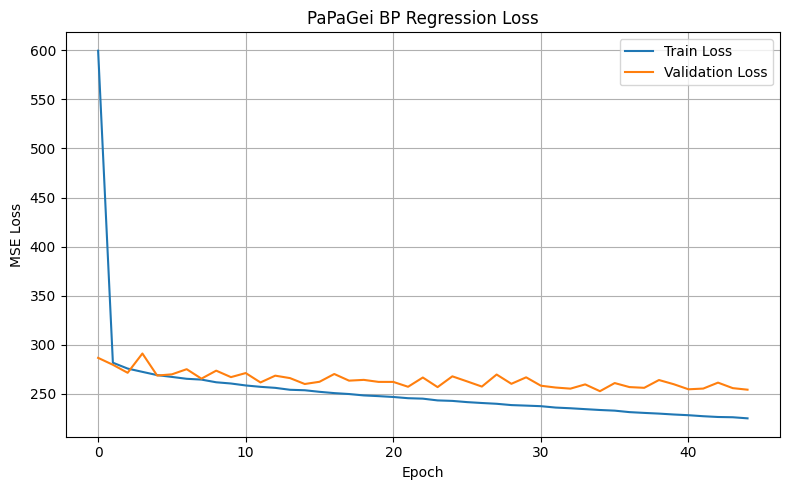

In [ ]:
import matplotlib.pyplot as plt
train_losses = history["train_loss"]
val_losses = history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PaPaGei BP Regression Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
predictions, targets, metrics = evaluate_model(
    bp_model,
    test_feature_loader,
    device
)

SBP MAE: 15.84 mmHg
DBP MAE: 7.89 mmHg
SBP RMSE: 20.11 mmHg
DBP RMSE: 10.59 mmHg


## Using PCA to reduce the dimensions and then try Regression ##

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# ==========================================
# PCA
# ==========================================

N_COMPONENTS = 50

pca = PCA(
    n_components=N_COMPONENTS,
    random_state=42
)

# IMPORTANT:
# Fit ONLY on training data
X_train_pca = pca.fit_transform(
    X_train_papagei
)

# Transform validation and test
X_val_pca = pca.transform(
    X_val_papagei
)

X_test_pca = pca.transform(
    X_test_papagei
)

In [ ]:
print("Original feature dimension:")
print(X_train_papagei.shape)

print("\nAfter PCA:")
print("Train:", X_train_pca.shape)
print("Val:  ", X_val_pca.shape)
print("Test: ", X_test_pca.shape)

Original feature dimension:
(369339, 512)

After PCA:
Train: (369339, 50)
Val:   (41747, 50)
Test:  (105582, 50)


In [ ]:
explained_variance = pca.explained_variance_ratio_

print(
    f"Variance explained by 50 components: "
    f"{explained_variance.sum():.4f}"
)

print(
    f"Variance explained: "
    f"{explained_variance.sum()*100:.2f}%"
)

Variance explained by 50 components: 0.9328
Variance explained: 93.28%


In [ ]:
train_feature_dataset = TensorDataset(
    torch.tensor(
        X_train_pca,
        dtype=torch.float32
    ),
    torch.tensor(
        y_train_papagei,
        dtype=torch.float32
    )
)

val_feature_dataset = TensorDataset(
    torch.tensor(
        X_val_pca,
        dtype=torch.float32
    ),
    torch.tensor(
        y_val_papagei,
        dtype=torch.float32
    )
)

test_feature_dataset = TensorDataset(
    torch.tensor(
        X_test_pca,
        dtype=torch.float32
    ),
    torch.tensor(
        y_test_papagei,
        dtype=torch.float32
    )
)

In [ ]:
BATCH_SIZE = 256

train_feature_loader = DataLoader(
    train_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_feature_loader = DataLoader(
    val_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_feature_loader = DataLoader(
    test_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
bp_model = BPRegressor(
    input_dim=50
).to(device)

# print(bp_model)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    bp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
p_model, history, best_val_loss = train_bp_model(
    bp_model=bp_model,
    train_feature_loader=train_feature_loader,
    val_feature_loader=val_feature_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=50,
    patience=10,
    min_delta=0.01,
    save_path="best_papagei_bp_regressor.pt"
)

Epoch 001/50 | Train Loss: 755.5822 | Val Loss: 291.3984 | Train SBP RMSE: 34.71 | Train DBP RMSE: 17.51 | Val SBP RMSE: 21.51 | Val DBP RMSE: 10.95 | Improved
Epoch 002/50 | Train Loss: 287.6432 | Val Loss: 285.4745 | Train SBP RMSE: 21.26 | Train DBP RMSE: 11.10 | Val SBP RMSE: 21.32 | Val DBP RMSE: 10.79 | Improved
Epoch 003/50 | Train Loss: 281.3980 | Val Loss: 282.8417 | Train SBP RMSE: 21.05 | Train DBP RMSE: 10.94 | Val SBP RMSE: 21.24 | Val DBP RMSE: 10.69 | Improved
Epoch 004/50 | Train Loss: 278.1805 | Val Loss: 276.8845 | Train SBP RMSE: 20.94 | Train DBP RMSE: 10.85 | Val SBP RMSE: 21.04 | Val DBP RMSE: 10.54 | Improved
Epoch 005/50 | Train Loss: 275.4388 | Val Loss: 276.6188 | Train SBP RMSE: 20.84 | Train DBP RMSE: 10.80 | Val SBP RMSE: 21.03 | Val DBP RMSE: 10.54 | Improved
Epoch 006/50 | Train Loss: 272.1858 | Val Loss: 273.0613 | Train SBP RMSE: 20.71 | Train DBP RMSE: 10.74 | Val SBP RMSE: 20.87 | Val DBP RMSE: 10.51 | Improved
Epoch 007/50 | Train Loss: 269.3677 | Va

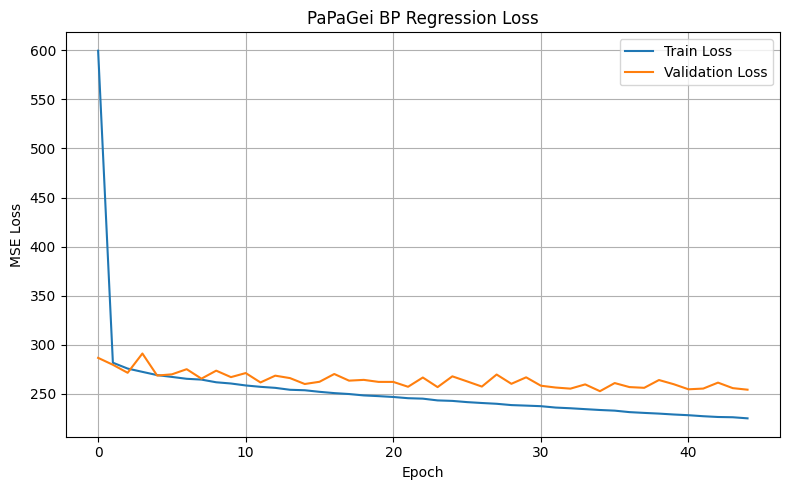

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PaPaGei BP Regression Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
bp_model.load_state_dict(
    torch.load(
        "best_papagei_bp_regressor.pt",
        map_location=device
    )
)

bp_model.eval()

BPRegressor(
  (regressor): Sequential(
    (0): Linear(in_features=50, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
predictions, targets, metrics = evaluate_model(
    bp_model,
    test_feature_loader,
    device
)

SBP MAE: 16.30 mmHg
DBP MAE: 8.06 mmHg
SBP RMSE: 20.52 mmHg
DBP RMSE: 10.75 mmHg


## Using Symbolic Regression on extracted features ##

In [ ]:
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
y_train_sbp = y_train_papagei[:, 0]
y_train_dbp = y_train_papagei[:, 1]

y_val_sbp = y_val_papagei[:, 0]
y_val_dbp = y_val_papagei[:, 1]

y_test_sbp = y_test_papagei[:, 0]
y_test_dbp = y_test_papagei[:, 1]

In [ ]:
from gplearn.genetic import SymbolicRegressor
from sklearn.utils.validation import check_X_y


def _validate_data(
    self,
    X,
    y,
    y_numeric=False,
    **kwargs
):
    X, y = check_X_y(
        X,
        y,
        y_numeric=y_numeric,
        **kwargs
    )

    # gplearn 0.4.2 expects this attribute
    self.n_features_in_ = X.shape[1]

    return X, y


SymbolicRegressor._validate_data = _validate_data

In [ ]:
from gplearn.fitness import make_fitness

def rmse(y, y_pred, w):
    if w is None:
        w = np.ones_like(y)

    return np.sqrt(
        np.average(
            (y - y_pred) ** 2,
            weights=w
        )
    )

rmse_fitness = make_fitness(
    function=rmse,
    greater_is_better=False
)

In [ ]:
sr = SymbolicRegressor(
    population_size=1000,
    generations=30,

    tournament_size=20,

    stopping_criteria=0.01,

    const_range=(-10.0, 10.0),

    init_depth=(2, 6),

    function_set=(
        "add",
        "sub",
        "mul",
        "div"
    ),

    metric=rmse_fitness,

    parsimony_coefficient=0.001,

    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,

    max_samples=0.9,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

In [ ]:
sr.fit(
    X_train_pca,
    y_train_sbp
)
sr.n_features_in_ = X_train_pca.shape[1]

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    22.81      3.63118e+06       15          69.2683          69.2975      8.12m
   1     4.08          140.126       15          69.1624          69.3809      6.99m
   2     7.39          265.863       27          60.6743          60.7195      8.09m
   3    13.87          242.746       17          22.6693          22.6216      7.16m
   4    16.62          9379.83       13          22.3593          22.4454      7.84m
   5    17.63          701.929        9          22.2732          22.4285      7.72m
   6    17.13          4162.55        9          22.2366          22.1786      8.61m
   7    15.61          186.655       15          22.2132          22.3873      7.21m
   8    10.68            337.5        9           22.212          22.3995  

In [ ]:
print(sr._program)

sub(sub(sub(sub(sub(sub(sub(mul(-8.333, add(-7.697, -7.697)), sub(sub(X9, sub(X12, X17)), X1)), sub(X36, sub(X13, X22))), sub(X9, sub(X12, X17))), sub(sub(sub(X47, X3), sub(X13, X22)), X4)), sub(sub(X12, sub(X12, sub(X23, X19))), X4)), X9), sub(sub(X9, div(X33, X33)), X1))


In [ ]:
sbp_test_pred = sr.predict(X_test_pca)

sbp_rmse = np.sqrt(
    np.mean(
        (y_test_sbp - sbp_test_pred) ** 2
    )
)


sbp_mae = np.mean(
    np.abs(
        y_test_sbp - sbp_test_pred
    )
)


print(f"SBP MAE  : {sbp_mae:.3f} mmHg")
print(f"SBP RMSE : {sbp_rmse:.3f} mmHg")


SBP MAE  : 17.624 mmHg
SBP RMSE : 21.936 mmHg


In [ ]:
sr.fit(
    X_train_pca,
    y_train_dbp
)
sr.n_features_in_ = X_train_pca.shape[1]

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    22.81      3.63114e+06       15          12.7911          12.7761      6.74m
   1     4.03          76.4222       15          12.3675           12.266      6.39m
   2     6.86          199.497       15           12.286          12.2047      8.00m
   3    13.59          165.721       13          11.6912          11.6286      6.98m
   4    14.69          8859.88        7          11.3894          11.3337      8.28m
   5    14.51           4211.2        7          11.3809           11.411      8.47m
   6    14.27          4029.07       13          11.2222          11.1293      8.32m
   7    13.09           122.37       15           11.203          11.2993      5.87m
   8    12.22          169.319       11           11.176          11.3149  

In [ ]:
dbp_test_pred = sr.predict(X_test_pca)

dbp_rmse = np.sqrt(
    np.mean(
        (y_test_dbp - dbp_test_pred) ** 2
    )
)


dbp_mae = np.mean(
    np.abs(
        y_test_dbp - dbp_test_pred
    )
)


print(f"DBP MAE  : {dbp_mae:.3f} mmHg")
print(f"DBP RMSE : {dbp_rmse:.3f} mmHg")

DBP MAE  : 8.672 mmHg
DBP RMSE : 11.284 mmHg


## Reducing the number of dimensions from 50 to 25 ##

In [ ]:
N_COMPONENTS = 25

pca = PCA(
    n_components=N_COMPONENTS,
    random_state=42
)

# IMPORTANT:
# Fit ONLY on training data
X_train_pca = pca.fit_transform(
    X_train_papagei
)

# Transform validation and test
X_val_pca = pca.transform(
    X_val_papagei
)

X_test_pca = pca.transform(
    X_test_papagei
)

In [ ]:
explained_variance = pca.explained_variance_ratio_

print(
    f"Variance explained by 50 components: "
    f"{explained_variance.sum():.4f}"
)

print(
    f"Variance explained: "
    f"{explained_variance.sum()*100:.2f}%"
)

Variance explained by 50 components: 0.8969
Variance explained: 89.69%


In [ ]:
sr.fit(
    X_train_pca,
    y_train_sbp
)
sr.n_features_in_ = X_train_pca.shape[1]

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    23.01      7.21722e+09        7          122.547          122.568      5.18m
   1     7.05           138.91       11          121.579          121.447      8.32m
   2    11.42          156.415        7          104.571           104.63      8.03m
   3    16.54          137.038       31          42.3983           42.335      8.20m
   4    22.75          16551.2       29          25.5833          25.5993      8.40m
   5    31.40            10697       29          23.5893          23.5053     10.38m
   6    32.10          152.383       29           23.376          23.4382      8.88m
   7    33.84          164.003       37          22.7364          22.7104      7.50m
   8    31.52          1124.57       27          22.5842          22.7557  

In [ ]:
print(sr._program)

sub(add(X12, add(add(add(X12, add(mul(-3.128, sub(-8.765, X13)), X1)), add(X7, X24)), add(X18, X1))), sub(add(sub(-8.765, X4), add(add(sub(-8.765, X4), add(X6, X9)), sub(X22, X12))), add(mul(-3.128, add(X9, -2.920)), mul(-8.730, -8.765))))


In [ ]:
sbp_test_pred = sr.predict(X_test_pca)

sbp_rmse = np.sqrt(
    np.mean(
        (y_test_sbp - sbp_test_pred) ** 2
    )
)


sbp_mae = np.mean(
    np.abs(
        y_test_sbp - sbp_test_pred
    )
)


print(f"SBP MAE  : {sbp_mae:.3f} mmHg")
print(f"SBP RMSE : {sbp_rmse:.3f} mmHg")


SBP MAE  : 17.709 mmHg
SBP RMSE : 21.931 mmHg


In [ ]:
sr.fit(
    X_train_pca,
    y_train_dbp
)
sr.n_features_in_ = X_train_pca.shape[1]

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    23.01      7.21722e+09        7          58.7885          58.8181      3.76m
   1     6.08          73.0189       11          57.8146          57.7795      6.12m
   2     8.83          91.4947       11          47.3931          47.4918      6.84m
   3    11.72          72.6107       31          14.1942          14.0527      7.27m
   4    17.53          16378.2       41          12.1088          12.0958      6.53m
   5    24.64          10615.9       33          11.2536          11.2164      8.15m
   6    29.58          95.5577       33          11.2438          11.3041      7.60m
   7    29.78            78.86       33           11.223          11.2477      7.01m
   8    27.48          1116.75       33             11.2          11.2083  

In [ ]:
dbp_test_pred = sr.predict(X_test_pca)

dbp_rmse = np.sqrt(
    np.mean(
        (y_test_dbp - dbp_test_pred) ** 2
    )
)


dbp_mae = np.mean(
    np.abs(
        y_test_dbp - dbp_test_pred
    )
)


print(f"DBP MAE  : {dbp_mae:.3f} mmHg")
print(f"DBP RMSE : {dbp_rmse:.3f} mmHg")

DBP MAE  : 8.598 mmHg
DBP RMSE : 11.179 mmHg


## Custom Kernels using SR ##